# CSI object detector training (v4)

Interactive version of `train_object_detector.py`.

**Before running:** from repo root, sync deps once:
```bash
cd csi_pipeline_new
uv sync --project .. --group csi
```

**Data:** default CSV is `exports/training_packets.csv`. Either export manually:
```bash
./run_detect.sh --train-from-db --include baseline_no_human,object_with_human
```
or set `EXPORT_FROM_DB = True` in the next cell.

**Honest metric:** `[A] session-grouped CV` — target **> ~0.65** with negative control **~0.5**.

**Models compared:** `hgb`, `rf`, `logreg`, `xgb`, `lgbm`, `catboost` (last three need `uv sync --group csi`).

In [1]:
from pathlib import Path
import subprocess
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)

# Run with cwd = csi_pipeline_new/ (recommended)
PIPE = Path.cwd()
if not (PIPE / "csi_features.py").exists():
    PIPE = Path.cwd() / "csi_pipeline_new"
sys.path.insert(0, str(PIPE))

from csi_features import (
    FEATURE_VERSION,
    LABEL_EMPTY,
    LABEL_OBJECT,
    FeatureConfig,
    WindowSpec,
    compute_baseline_phase_profile,
    compute_baseline_profile,
)
from train_object_detector import (
    blocked_split,
    build_pipeline,
    build_windows,
    candidate_models,
    group_cv_feasibility,
    grouped_cv,
    holdout_balanced_accuracy,
    leakage_baselines,
    load_packets,
    negative_control,
    save_bundle,
    select_best_model,
    select_best_model_grouped,
    subdivide_groups,
    tune_threshold,
)

REPO = PIPE.parent
CSV_PATH = PIPE / "exports" / "training_packets.csv"
MODEL_OUT = PIPE / "models" / "object_detector.joblib"

# Set True to export Postgres → CSV before loading (needs DATABASE_URL)
EXPORT_FROM_DB = False
INCLUDE_LABELS = "baseline_no_human,object_with_human"

WINDOW = 30
STRIDE = 15
TEST_FRACTION = 0.2
SEED = 42
TIME_BLOCKS = 4
DEPLOY_ON_ALL = True  # refit best model on all windows after eval

CONFIG = FeatureConfig()  # v4: gain-normalized amp + phase; meta off

print(f"pipeline dir: {PIPE}")
print(f"csv: {CSV_PATH}")
print(f"models available: {sorted(candidate_models().keys())}")
print(f"feature version: v{FEATURE_VERSION}  [{CONFIG.describe()}]")

pipeline dir: /Users/saikarthik/Desktop/camera_module/csi_pipeline
csv: /Users/saikarthik/Desktop/camera_module/sample_data/csi_packets.csv
feature version: v4  [gain-normalized+phase]


In [2]:
if EXPORT_FROM_DB:
    cmd = [
        "uv", "run", "--project", str(REPO), "--group", "csi", "python",
        str(PIPE / "export_training_csv.py"),
        "--out", str(CSV_PATH),
        "--include", INCLUDE_LABELS,
    ]
    print(" ".join(cmd))
    subprocess.run(cmd, cwd=PIPE, check=True)

assert CSV_PATH.is_file(), (
    f"CSV not found: {CSV_PATH}\n"
    "Run: ./run_detect.sh --train-from-db --include baseline_no_human,object_with_human"
)

packets, labels, session_labels, session_keys = load_packets(CSV_PATH, config=CONFIG)
print(f"packets: {len(packets):,}")
print(f"  empty:  {labels.count(LABEL_EMPTY):,}")
print(f"  object: {labels.count(LABEL_OBJECT):,}")
print(f"sessions: {len(set(session_keys))} keys  labels={sorted(set(session_labels))}")
pd.Series(session_keys).value_counts().head(10)

skip bad iq row: expected 234 iq ints, got 76


skip bad iq row: expected 234 iq ints, got 364
skip bad iq row: expected 234 iq ints, got 282


skip bad iq row: expected 234 iq ints, got 347


packets: 34,045
  empty:  16,839
  object: 17,206
sessions: 2 keys  labels=['baseline_1hr', 'object_1hr']


In [3]:
baseline_profile = compute_baseline_profile(packets, labels)
baseline_phase = compute_baseline_phase_profile(packets, labels) if CONFIG.use_phase else None
spec = WindowSpec(size=WINDOW, stride=STRIDE)

ws = build_windows(
    packets, labels, session_labels, spec, baseline_profile, baseline_phase,
    config=CONFIG, session_keys=session_keys,
)
X, y = ws.X, ws.y

print(f"windows: {len(y):,}  features: {X.shape[1]}  (v{FEATURE_VERSION})")
print(f"class balance: empty={int((y == 0).sum())}  object={int((y == 1).sum())}")
print(f"median window span: {ws.median_span_s:.1f}s")
print(f"rejected: {ws.dropped_discontiguous} discontiguous, {ws.dropped_mixed_label} mixed-label")

pd.Series(ws.groups).value_counts()

windows: 2,255  features: 1032  (v4)
class balance: empty=1115  object=1140
median window span: 2.2s
rejected: 12 discontiguous, 0 mixed-label


object_1hr#1      1140
baseline_1hr#0    1115
Name: count, dtype: int64

In [4]:
# Leakage baselines + session-grouped CV for every candidate model.
# Trust [A] only — time-block / hold-out can look great when label = session.

print("metadata-only, one threshold, in-sample:")
display(pd.DataFrame(leakage_baselines(ws)).T.round(3))

feasible, why = group_cv_feasibility(ws.y, ws.groups)

rows = []
if feasible:
    for name in candidate_models():
        g = grouped_cv(name, ws.X, ws.y, ws.groups)
        if g.get("folds", 0):
            rows.append({
                "model": name,
                "bal_acc": g["balanced_accuracy"],
                "bal_std": g.get("balanced_accuracy_std", float("nan")),
                "roc_auc": g["roc_auc"],
                "folds": int(g["folds"]),
            })
    gm = grouped_cv("hgb", ws.meta, ws.y, ws.groups)
    rows.append({
        "model": "meta/hgb",
        "bal_acc": gm.get("balanced_accuracy", float("nan")),
        "bal_std": gm.get("balanced_accuracy_std", float("nan")),
        "roc_auc": gm.get("roc_auc", float("nan")),
        "folds": int(gm.get("folds", 0)),
    })
    cv_df = pd.DataFrame(rows).sort_values("bal_acc", ascending=False)
    print("\n[A] Session-grouped CV (honest — generalization to unseen capture):")
    display(cv_df.round(3))
else:
    print(f"\n[A] session-grouped CV NOT POSSIBLE — {why}\n")
    print("Fix: interleaved capture — 2 min empty ↔ 2 min object, repeat.")
    cv_df = None

# [B] time-block CV (often confounded)
block_groups = subdivide_groups(ws, TIME_BLOCKS)
if TIME_BLOCKS > 1 and group_cv_feasibility(ws.y, block_groups)[0]:
    block_rows = []
    for name in candidate_models():
        g = grouped_cv(name, ws.X, ws.y, block_groups)
        if g.get("folds", 0):
            block_rows.append({"model": name, "bal_acc": g["balanced_accuracy"], "folds": int(g["folds"])})
    print(f"\n[B] Time-block CV ({TIME_BLOCKS} blocks/session) — often misleading:")
    display(pd.DataFrame(block_rows).sort_values("bal_acc", ascending=False).round(3))

metadata-only, one threshold, in-sample:


,balanced_accuracy,accuracy,threshold
mean RSSI,0.983,0.983,-47.767
mean AGC gain,0.970,0.970,35.967
mean FFT gain,0.901,0.900,16.800



session-grouped CV NOT POSSIBLE — 2 groups, 2 of them single-class; empty appears in 1 group(s), object in 1. Holding out a group removes an entire class from training.

Everything below is therefore confounded: label and session
coincide, so a model can score well by recognizing the recording.
Fix: capture interleaved A/B/A/B blocks of ~2 min each.


In [5]:
# Temporal hold-out. FALLBACK ONLY: both sides come from the same recordings,
# so it cannot see a label/session confound. It is used for model selection
# below only when session-grouped CV is impossible.
X_train, X_test, y_train, y_test = blocked_split(
    ws.X, ws.y, ws.groups, test_fraction=TEST_FRACTION, seed=SEED
)
print(f"train: {len(y_train):,}  hold-out: {len(y_test):,}")

# Same split, receiver state only — the number the CSI model has to beat.
meta_holdout = holdout_balanced_accuracy(
    ws.meta, ws.y, ws.groups, test_fraction=TEST_FRACTION, seed=SEED
)
print(f"meta-only on this split: bal_acc={meta_holdout:.3f}")

train: 1,804  hold-out: 451


meta-only on this split: bal_acc=0.888


In [6]:
# When grouped CV is available it drives everything: which model, which
# threshold, and the metrics that go into the bundle. No candidate is ever
# scored on a session it was trained on. Otherwise fall back to the hold-out
# and flag the bundle as untrustworthy.
if feasible:
    model_name, threshold, _grouped_metrics, model_scores, oof = select_best_model_grouped(
        ws.X, ws.y, ws.groups
    )
    assert model_name, "grouped selection produced no usable fold"
    eval_pipe = build_pipeline(model_name)
    eval_pipe.fit(ws.X, ws.y)          # metrics above already estimate generalization
    scored = ~np.isnan(oof)
    y_eval, proba_eval = ws.y[scored], oof[scored]
    PROTOCOL = "session-grouped out-of-fold"
else:
    model_name, eval_pipe, threshold, model_scores = select_best_model(
        X_train, y_train, X_test, y_test
    )
    y_eval = y_test
    proba_eval = eval_pipe.predict_proba(X_test)[:, LABEL_OBJECT]
    PROTOCOL = "temporal hold-out (FALLBACK — confounded)"

scores_df = pd.Series(model_scores, name="bal_acc").sort_values(ascending=False)
print(f"Model selection — {PROTOCOL}:")
display(scores_df.to_frame())
print(f"\nSelected: {model_name}  threshold={threshold:.2f}  "
      f"scored on {len(y_eval):,} windows")

  candidate hgb: min_recall=0.812  bal_acc=0.906  thr=0.15


Model selection — temporal hold-out (FALLBACK — confounded):


  candidate rf: min_recall=0.812  bal_acc=0.906  thr=0.84
  candidate logreg: min_recall=0.785  bal_acc=0.892  thr=0.15


,bal_acc
hgb,0.905830
rf,0.905830
logreg,0.892377



Selected: hgb  threshold=0.15  scored on 451 windows


accuracy                                              0.906874
balanced_accuracy                                      0.90583
object_f1                                             0.915663
empty_f1                                               0.89604
protocol             temporal hold-out (FALLBACK — confounded)
roc_auc                                                0.90583
Name: temporal hold-out (FALLBACK — confounded), dtype: object

              precision    recall  f1-score   support

       empty       1.00      0.81      0.90       223
      object       0.84      1.00      0.92       228

    accuracy                           0.91       451
   macro avg       0.92      0.91      0.91       451
weighted avg       0.92      0.91      0.91       451



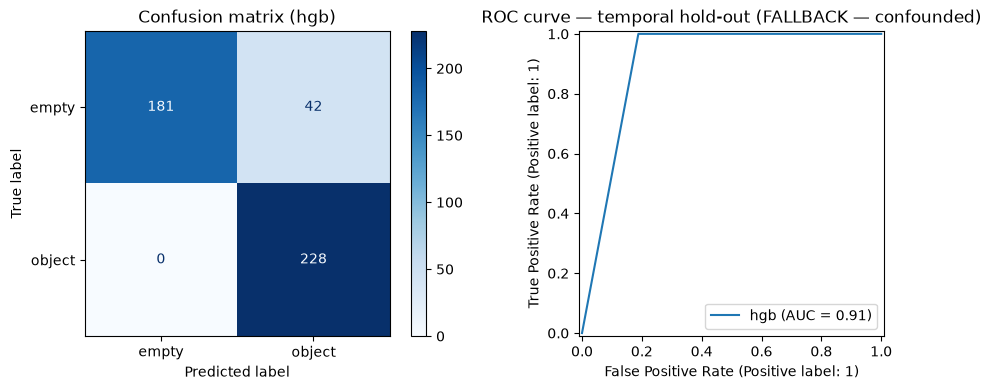

In [7]:
pred_eval = (proba_eval >= threshold).astype(int)

metrics = {
    "accuracy": float(accuracy_score(y_eval, pred_eval)),
    "balanced_accuracy": float(balanced_accuracy_score(y_eval, pred_eval)),
    "object_f1": float(f1_score(y_eval, pred_eval, pos_label=LABEL_OBJECT, zero_division=0)),
    "empty_f1": float(f1_score(y_eval, pred_eval, pos_label=LABEL_EMPTY, zero_division=0)),
    "protocol": PROTOCOL,
}
if len(np.unique(y_eval)) > 1:
    metrics["roc_auc"] = float(roc_auc_score(y_eval, proba_eval))

display(pd.Series(metrics, name=PROTOCOL))
print(classification_report(y_eval, pred_eval, target_names=["empty", "object"]))

cm = confusion_matrix(y_eval, pred_eval, labels=[LABEL_EMPTY, LABEL_OBJECT])
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(cm, display_labels=["empty", "object"]).plot(ax=axes[0], cmap="Blues")
axes[0].set_title(f"Confusion matrix ({model_name})")
RocCurveDisplay.from_predictions(y_eval, proba_eval, ax=axes[1], name=model_name)
axes[1].set_title(f"ROC curve — {PROTOCOL}")
plt.tight_layout()
plt.show()

In [8]:
# Optional: force a specific model instead of grouped selection
# FORCE_MODEL = "xgb"  # hgb | rf | logreg | xgb | lgbm | catboost
# pipe = build_pipeline(FORCE_MODEL)
# pipe.fit(X_train, y_train)
# proba_eval = pipe.predict_proba(X_test)[:, LABEL_OBJECT]
# y_eval = y_test
# threshold, _ = tune_threshold(y_test, proba_eval)
# model_name, eval_pipe = FORCE_MODEL, pipe

In [9]:
# Negative control + save bundle
nc = negative_control(
    packets, labels, spec, config=CONFIG, test_fraction=TEST_FRACTION, seed=SEED
)
if nc:
    print(f"empty-vs-empty: bal_acc={nc['balanced_accuracy']:.3f}  "
          f"auc={nc['roc_auc']:.3f}  over {int(nc['windows']):,} windows   (0.5 = clean)")
else:
    print("negative control skipped — not enough empty windows")

nc_bad = bool(nc) and nc["balanced_accuracy"] >= 0.60
trustworthy = feasible and not nc_bad
if not feasible:
    note = why
elif nc_bad:
    note = (f"empty-vs-empty negative control scores {nc['balanced_accuracy']:.3f}; "
            "an object-free room reproduces the signal")
else:
    note = ""
print(f"trustworthy={trustworthy}  {note}")

if DEPLOY_ON_ALL and feasible:
    pipe = eval_pipe
elif DEPLOY_ON_ALL:
    print(f"Retraining {model_name} on all {len(ws.y):,} windows …")
    pipe = build_pipeline(model_name)
    pipe.fit(ws.X, ws.y)
    threshold, _ = tune_threshold(y_test, pipe.predict_proba(X_test)[:, LABEL_OBJECT])
else:
    pipe = eval_pipe

save_bundle(
    MODEL_OUT,
    pipe=pipe,
    spec=spec,
    config=CONFIG,
    baseline_profile=baseline_profile,
    baseline_phase=baseline_phase,
    threshold=threshold,
    model_type=model_name,
    csv_path=CSV_PATH,
    metrics=metrics,
    negative_control_metrics=nc or None,
    evaluation_trustworthy=trustworthy,
    evaluation_note=note,
    leakage=leakage_baselines(ws),
    session_keys=session_keys,
    packet_count=len(packets),
)
print(f"Saved → {MODEL_OUT}")
print("Live:  ./run_detect.sh --calibrate && ./run_detect.sh --fast --quiet")

empty-vs-empty: bal_acc=0.920  auc=0.946  over 1,114 windows   (0.5 = clean)
trustworthy=False  2 groups, 2 of them single-class; empty appears in 1 group(s), object in 1. Holding out a group removes an entire class from training.
Retraining hgb on all 2,255 windows …


Saved → /Users/saikarthik/Desktop/camera_module/csi_pipeline/models/object_detector.joblib
Live:  cd csi_pipeline && ./run_detect.sh --fast --quiet


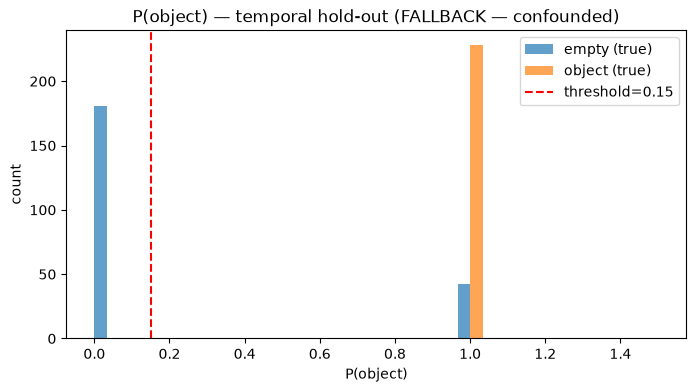

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(proba_eval[y_eval == LABEL_EMPTY], bins=30, alpha=0.7, label="empty (true)")
ax.hist(proba_eval[y_eval == LABEL_OBJECT], bins=30, alpha=0.7, label="object (true)")
ax.axvline(threshold, color="red", linestyle="--", label=f"threshold={threshold:.2f}")
ax.set_xlabel("P(object)")
ax.set_ylabel("count")
ax.set_title(f"P(object) — {PROTOCOL}")
ax.legend()
plt.show()